<div style="
    background: linear-gradient(90deg, #4b6cb7 0%, #182848 100%);
    padding: 25px;
    border-radius: 15px;
    text-align: center;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
">
    <h1 style="color: white; margin: 0; letter-spacing: 2px; text-transform: uppercase; font-size: 24px;">
        Исследовательский блокнот проекта "Прогнозирование энерговыработки на солнечной электростанции при помощи модели машинного обучения"
    </h1>
    <hr style="border: 0; height: 1px; background: rgba(255,255,255,0.3); margin: 15px auto; width: 50%;">
    <span style="color: #d1d1d1; font-style: italic;">🧠 Большие данные, искусственный интеллект, автоматизированные системы и информационная безопасность</span>
</div>


## <center>Импорт библиотек</center>

In [14]:
import datetime as dt
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import TimeSeriesSplit

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
)

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', 1001)
pd.set_option('display.max_columns', 60)

sns.set(style="whitegrid")

## <center>Соединение 2х data-frame-ов (выработки и исторических данных о погоде):</center>

Подгрузка данных о погоде

In [15]:
historical_weather = pd.read_csv('historical_weather.csv', index_col=0) 

Подгрузка данных о выработке

In [16]:
production = pd.read_excel('production.xlsx')

Приведение данных об исторической энерговыработке к числовому формату 

In [17]:
production['production'] = pd.to_numeric(production['production'], errors='coerce')

Удаление дубликатов в данных об исторической энерговыработке

In [ ]:
production.drop_duplicates() 

,date,id_station,production
0,2023-12-31,16,110.000
1,2024-01-01,16,240.000
2,2024-01-02,16,640.000
3,2024-01-03,16,60.000
4,2024-01-04,16,480.000
...,...,...,...
7010,2025-06-16,11,49207.010
7011,2025-06-16,16,4670.000
7012,2025-06-16,14,1430.000
7013,2025-06-16,15,760.000


Объединение исторических данных о погоде и выработаботке

In [ ]:
historical_weather["date"] = pd.to_datetime(historical_weather['date']).dt.date # приведение к формату datetime колонки date
production["date"] = pd.to_datetime(production["date"]).dt.date

meteo_and_prod = pd.merge(
    historical_weather,
    production,
    on='date',
    how='left',
)

meteo_and_prod.head()

sum_columns = ['global_tilted_irradiance', 'direct_normal_irradiance', 'direct_radiation', 'diffuse_radiation', 'terrestrial_radiation', 'shortwave_radiation'] # суммируемые колонки
mean_columns = ['cloud_cover', 'relative_humidity_2m', 'temperature_2m', 
                        'wind_speed_10m', 'surface_pressure'] 

for col in meteo_and_prod.columns:
    if col not in ['id_station', 'date', 'production']:
        if col in mean_columns and pd.api.types.is_numeric_dtype(meteo_and_prod[col]):
            mean_columns.append(col) if col not in mean_columns else None
        elif pd.api.types.is_numeric_dtype(meteo_and_prod[col]):
            sum_columns.append(col)
    
agg_dict = {}
for col in sum_columns:
    agg_dict[col] = 'sum'
for col in mean_columns:
    if col in meteo_and_prod.columns and pd.api.types.is_numeric_dtype(meteo_and_prod[col]):
        agg_dict[col] = 'mean'
    
if 'production' in meteo_and_prod.columns:
    agg_dict['production'] = 'first'
        
meteo_and_prod = (
    meteo_and_prod.groupby(['id_station', 'date'])
    .agg(agg_dict)
    .reset_index()
)

meteo_and_prod['production'] = meteo_and_prod['production'].round(2)

meteo_and_prod.head()


,id_station,date,global_tilted_irradiance,direct_normal_irradiance,direct_radiation,diffuse_radiation,terrestrial_radiation,shortwave_radiation,cloud_cover,relative_humidity_2m,temperature_2m,wind_speed_10m,surface_pressure,production
0,1,2024-01-31,1211,1510.800,338,873,2502.400,1211,83.458,86.917,-6.475,16.704,989.471,27551.200
1,1,2024-02-01,899,261.700,69,830,2554.200,899,100.000,91.375,-10.383,12.896,983.646,27869.180
2,1,2024-02-02,380,0.000,0,380,2606.800,380,100.000,93.667,-4.550,15.700,972.000,29016.500
3,1,2024-02-03,792,412.500,95,697,2660.400,792,98.083,88.958,-4.675,17.787,968.208,18959.070
4,1,2024-02-04,585,8.300,2,583,2718.300,585,100.000,91.792,-4.862,17.767,964.742,10237.500


## <center>Обработка итогового data-frame-а (c данными о выработке и историческими данными о погоде):</center>

Сортировка по дате данных

In [22]:
meteo_and_prod.sort_values(by='date', inplace=True)

Вычисление межквартального размаха на тестовых данных и удаление выбросов 

In [23]:
test_data = meteo_and_prod.iloc[0:int(len(meteo_and_prod) * 0.8)]

test_data.drop(columns=['date'], inplace=True)

q1 = test_data['production'].quantile(0.25) 
q3 = test_data['production'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr 
upper_bound = q3 + 1.5 * iqr

meteo_and_prod.loc[(meteo_and_prod['production'] < lower_bound) | (meteo_and_prod['production'] > upper_bound), 'production'] = np.nan

Удаление пропусков

In [24]:
meteo_and_prod.dropna(subset='production', inplace=True)

## <center>Построение корреляционной матрицы</center>

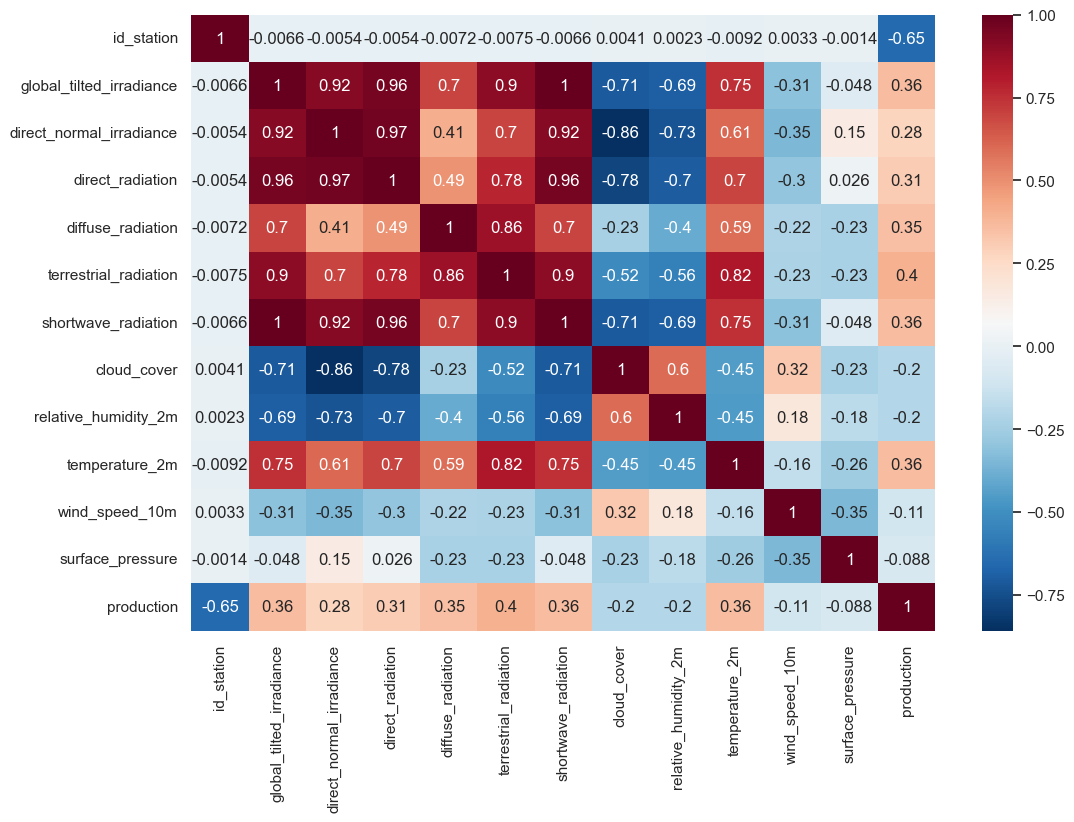

In [25]:
plt.figure(figsize=(12, 8))
sns.heatmap(test_data.corr(), annot=True, cmap='RdBu_r')
plt.show()

# <center>Подготовка к обучению моделей</center>

Инициализация функции для расчета WAPE

In [13]:
def wape(y_pred, y_true):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

Инициализация функции для построения диаграм рассеивания


In [ ]:
def plot_predictions_vs_true(y_pred, y):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred, y=y, alpha=0.3)

    max_val = max(y.max(), y_pred.max())

    plt.plot([0, max_val], [0, max_val], c='r', linestyle='--')
    
    plt.title(f"MAE: {mean_absolute_error(y_pred, y):.2f}, R2: {r2_score(y_pred, y):.2f}, WAPE: {wape(y_pred, y):.2f}")
    plt.xlabel("Предсказание")
    plt.ylabel("Выработка")
    plt.legend()
    plt.show()


Создание DataFrame-а с обработанными данными

In [15]:
processed_meteo_and_prod = meteo_and_prod.copy()

processed_meteo_and_prod = processed_meteo_and_prod.drop(columns=['global_tilted_irradiance', 'direct_normal_irradiance', 'direct_radiation', 'shortwave_radiation'])

Деление обработанных (без избыточных и мультиколлинеарных признаков) и необработанных данных на обучающие (DataFrame с метеопризнаками) и тестовые (Series с целевой переменной-production)

In [16]:
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(processed_meteo_and_prod.drop(columns=['production', 'date']),
                                                    processed_meteo_and_prod['production'], 
                                                    test_size=0.2) # ..._p - processed (обработанные)

x_train, x_test, y_train, y_test = train_test_split(meteo_and_prod.drop(columns=['production', 'date']),
                                                    meteo_and_prod['production'], 
                                                    test_size=0.2)


Создание экземпляра TimeSeriesSplit для специальной настройки моделей, которая не дает им заглядывать в будующее (специальный инструмент для кросс-валидации временных рядов, где критически важен порядок данных)

In [17]:
tscv = TimeSeriesSplit(n_splits=10) # n_splits - количество разбиений данных при кросс-валидации

Установка random_state

In [18]:
RANDOM_STATE = 42 # так называемый "ключ" для фиксации результатов

Установка количества итераций поиска для RandomizedSearchCV и HalvingRandomSearchCV

In [19]:
N_ITER_SEARCH = 60 

Установка максимального количества поколений для нейронной сети 

In [20]:
MAX_ITERATIONS = 500  

# <center>Обучение моделей</center>

Инициализация сетки параметров для дерева решений и случайного леса

In [ ]:
param_grid_for_trees = { 
    'max_depth': [5, 10, 15, None], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.01],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

## Дерево решений

### GridSearchCV

#### На необработанных данных

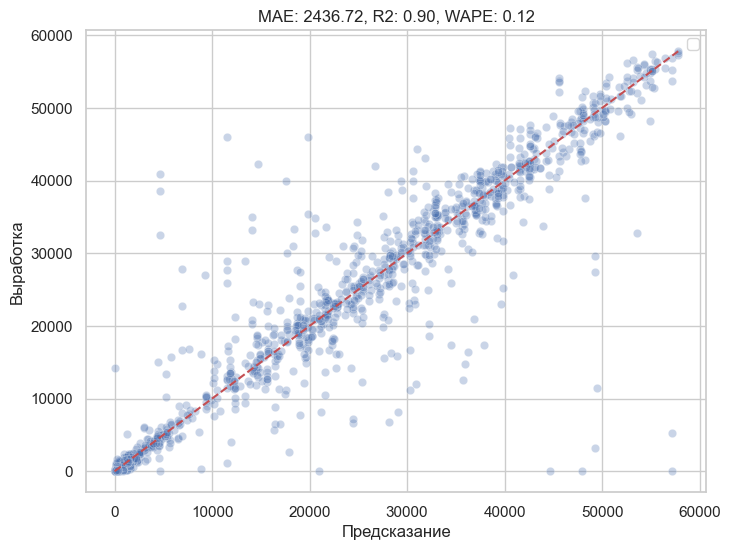

In [ ]:
decisionTree_GSCV = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_for_trees, 
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    refit='average_error', 
    n_jobs=-1 
)

decisionTree_GSCV.fit(x_train, y_train)
plot_predictions_vs_true(decisionTree_GSCV.predict(x_test), y_test)


#### На обработанных данных

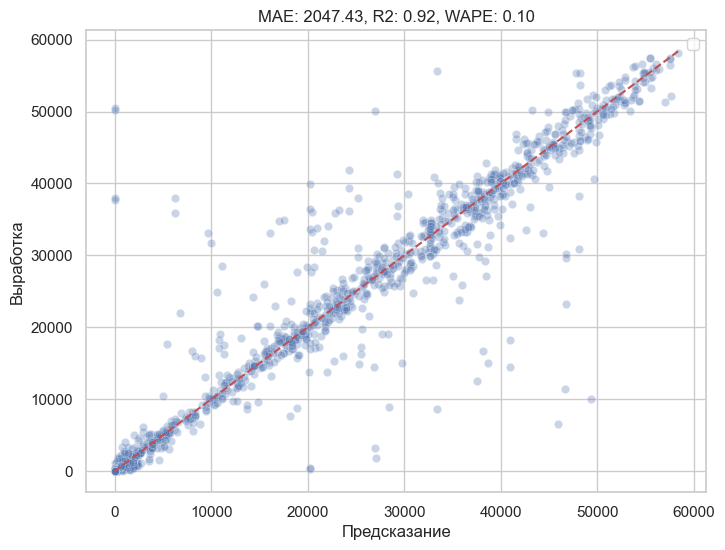

In [ ]:
decisionTree_GSCV = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_for_trees, 
    cv=tscv,
    scoring={
        'accuracy_r2': 'r2',
        'average_error': 'neg_mean_absolute_error'
    },
    refit='average_error', 
    n_jobs=-1 
)

decisionTree_GSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(decisionTree_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

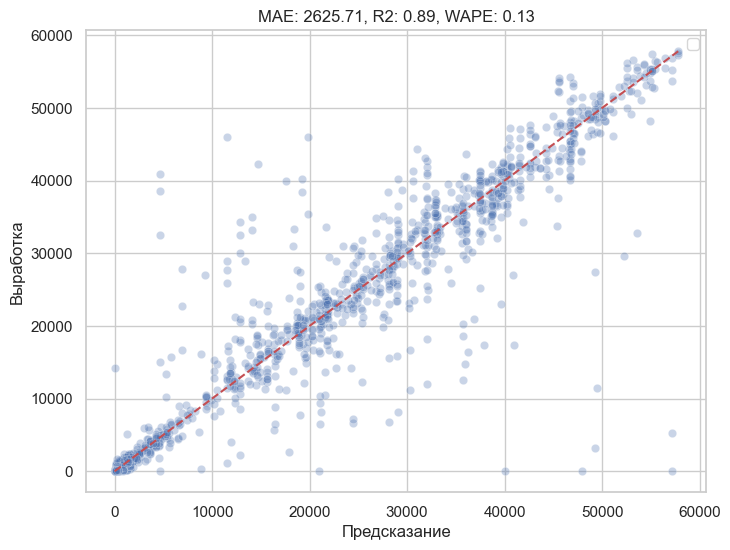

In [ ]:
decisionTree_RSCV = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees, 
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

decisionTree_RSCV.fit(x_train, y_train)

plot_predictions_vs_true(decisionTree_RSCV.predict(x_test), y_test)


#### На обработанных данных

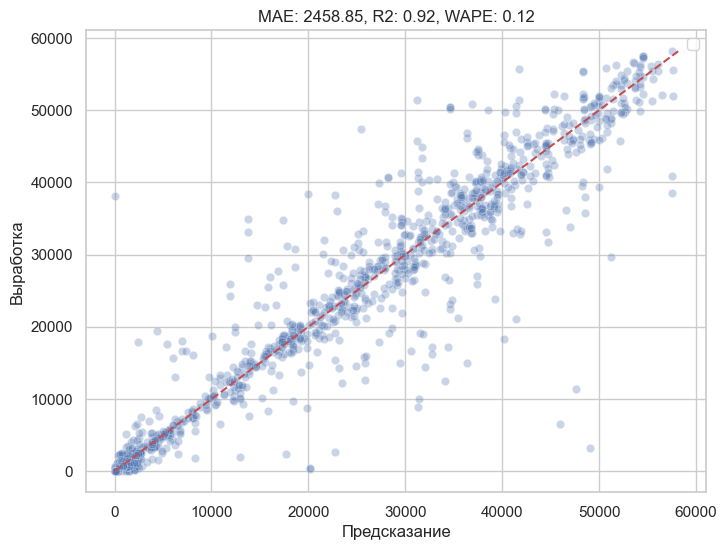

In [ ]:
decisionTree_RSCV = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees, 
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

decisionTree_RSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(decisionTree_RSCV.predict(x_test_p), y_test_p)


### HalvingGridSearchCV

#### На необработанных данных

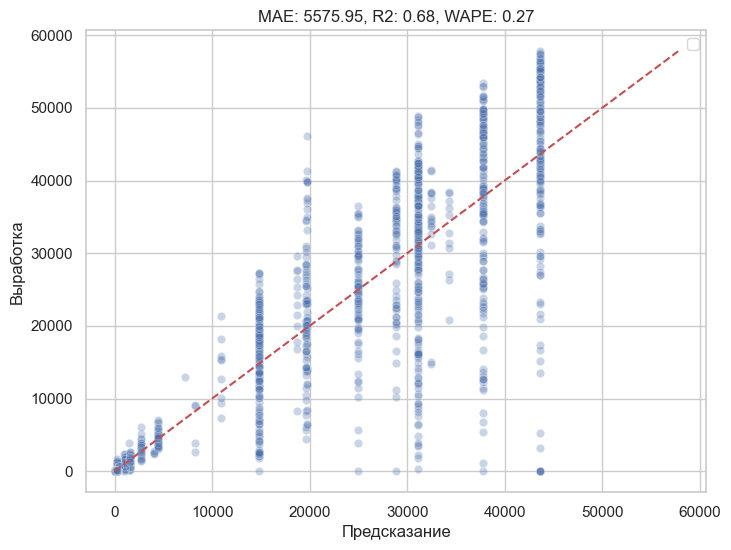

In [ ]:
decisionTree_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=2,
    resource='n_samples',
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HGSCV.fit(x_train, y_train)

plot_predictions_vs_true(decisionTree_HGSCV.predict(x_test), y_test)

#### На обработанных данных

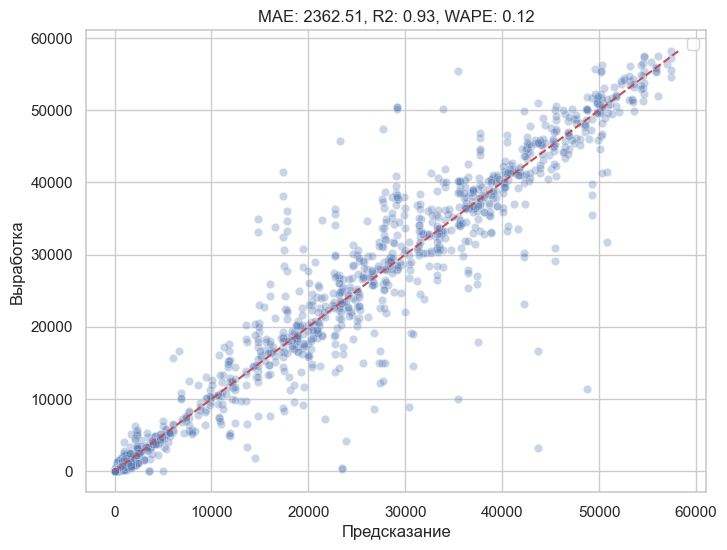

In [ ]:
decisionTree_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=2,
    resource='n_samples',
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HGSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(decisionTree_HGSCV.predict(x_test_p), y_test_p)

### HalvingRandomSearchCV

#### На необработанных данных

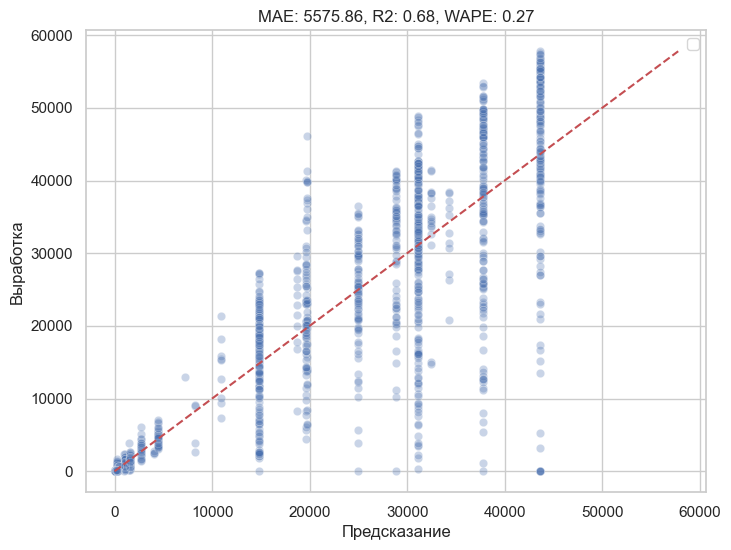

In [ ]:
decisionTree_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees,
    factor=3,
    resource='n_samples',
    n_candidates='exhaust',  
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HRSCV.fit(x_train, y_train)

plot_predictions_vs_true(decisionTree_HRSCV.predict(x_test), y_test)


#### На обработанных данных

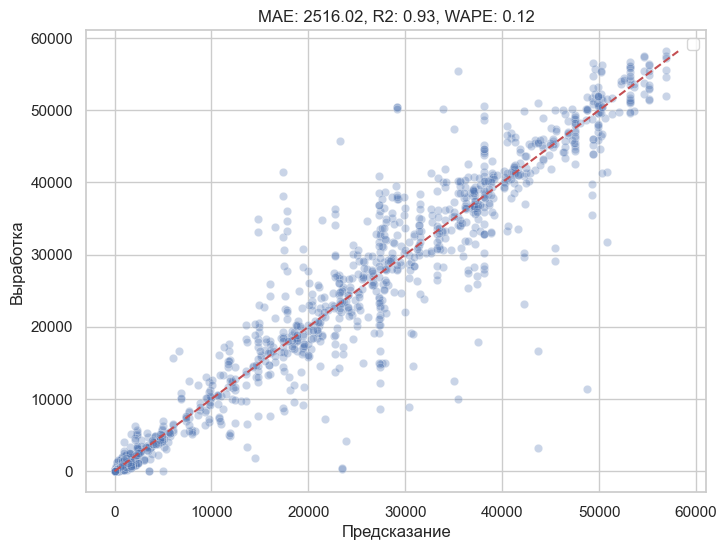

In [ ]:
decisionTree_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees,
    factor=3,
    resource='n_samples',
    n_candidates='exhaust',  
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HRSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(decisionTree_HRSCV.predict(x_test_p), y_test_p)


## Случайный лес


### GridSearchCV

#### На необработанных данных

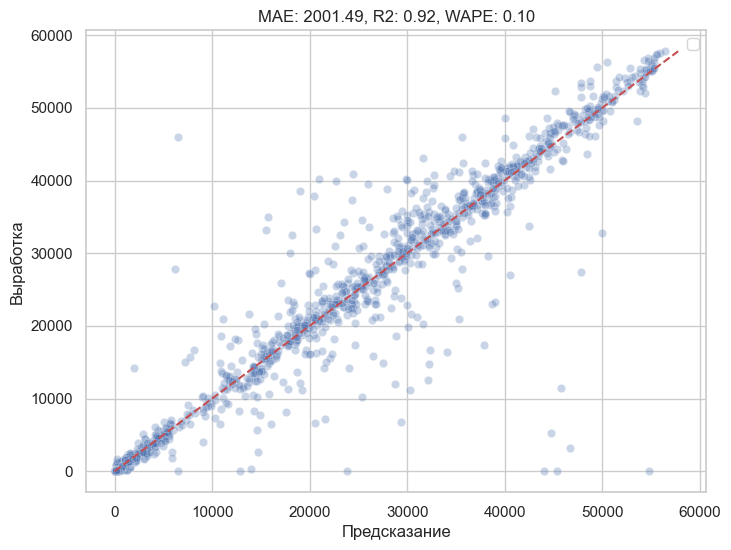

In [ ]:
random_forest_GSCV = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_for_trees,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

random_forest_GSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_GSCV.predict(x_test), y_test)


#### На обработанных данных

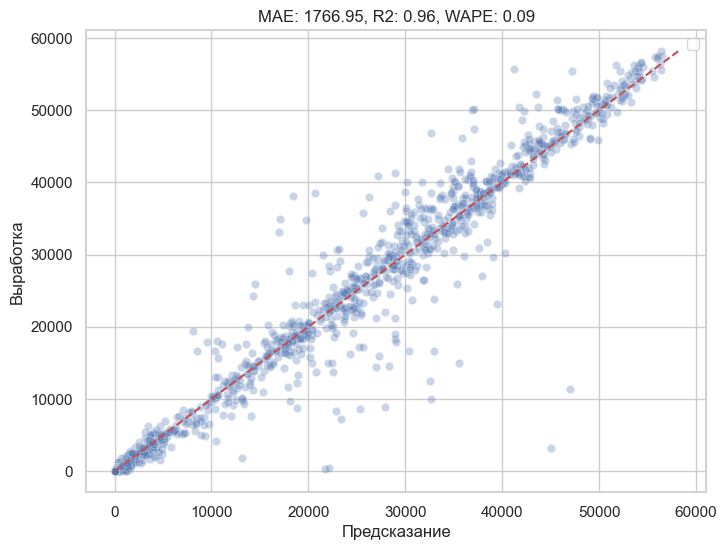

In [ ]:
random_forest_GSCV = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_for_trees,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

random_forest_GSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

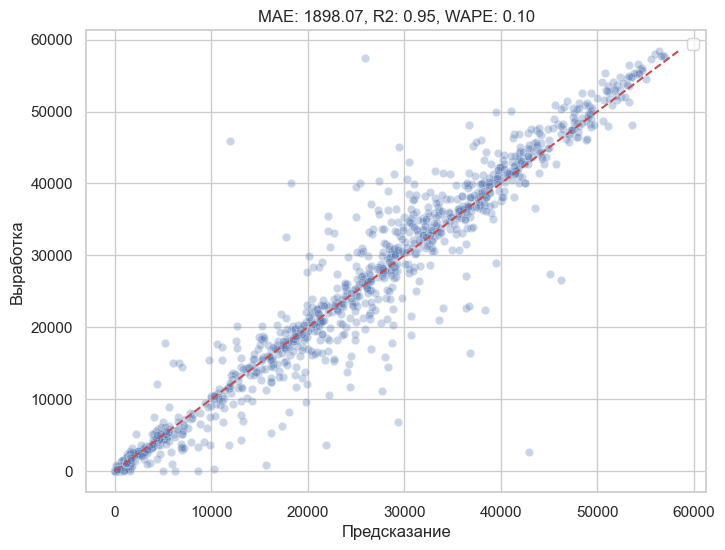

In [ ]:
random_forest_RSCV = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest_RSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_RSCV.predict(x_test), y_test)

#### На обработанных данных

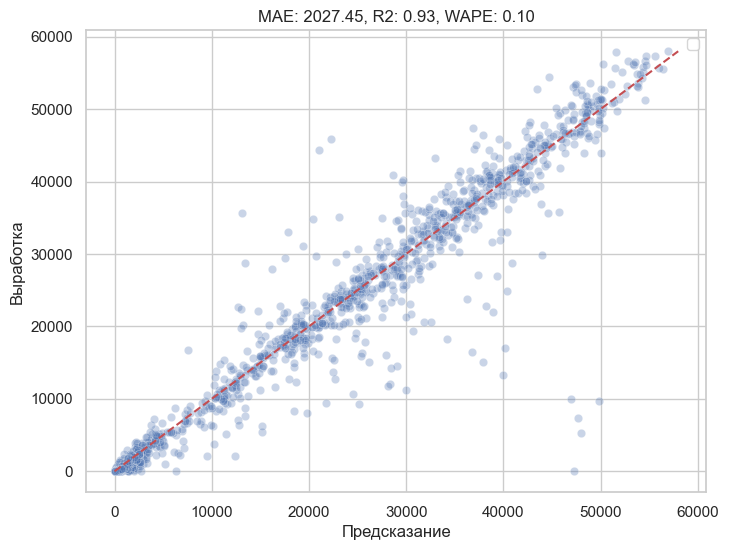

In [ ]:
random_forest_RSCV = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

random_forest_RSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_RSCV.predict(x_test_p), y_test_p)


### HalvingGridSearchCV

#### На необработанных данных

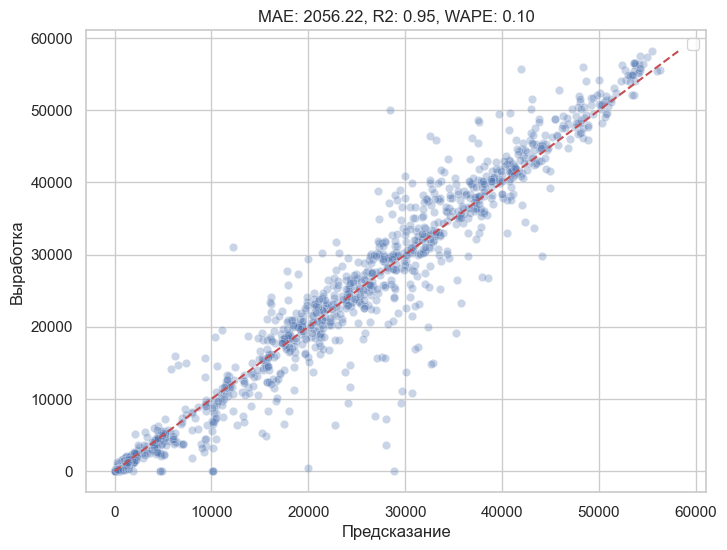

In [ ]:
random_forest_HSCV = enable_halving_search_cv.HalvingGridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',  
    max_resources='auto',   
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest_HSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_HSCV.predict(x_test), y_test)


#### На обработанных данных

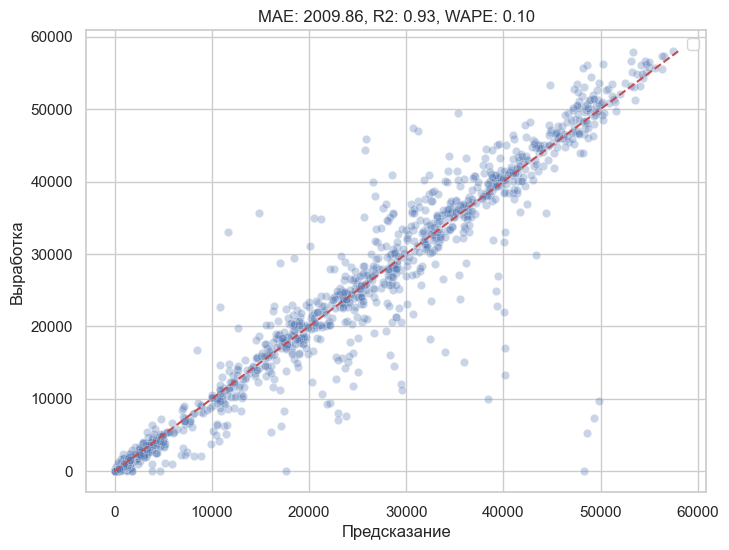

In [ ]:
random_forest_HSCV = enable_halving_search_cv.HalvingGridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',  
    max_resources='auto',   
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest_HSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_HSCV.predict(x_test_p), y_test_p)


### HalvingRandomSearchCV


#### На необработанных данных

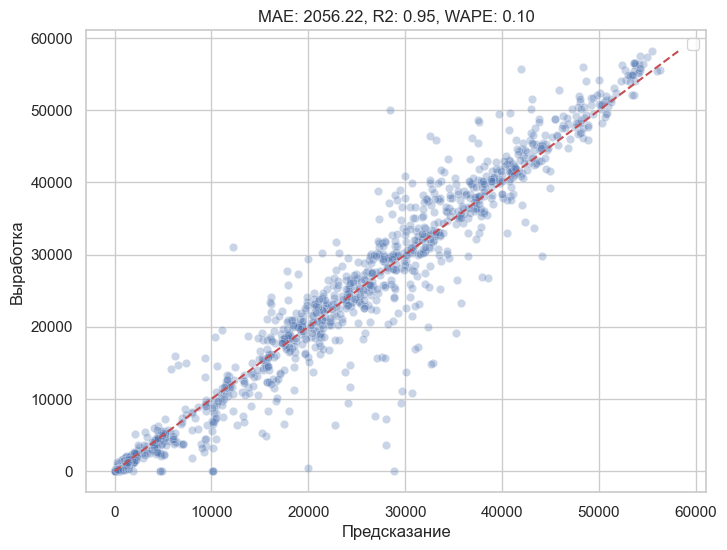

In [ ]:
random_forest_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',   
    max_resources='auto',  
    cv=tscv, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest_HRSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_HRSCV.predict(x_test), y_test)


#### На обработанных данных

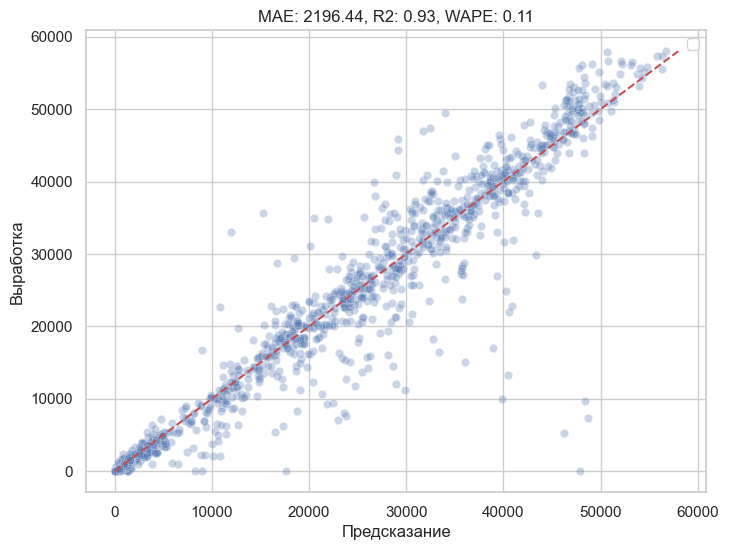

In [ ]:
random_forest_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',   
    max_resources='auto',  
    cv=tscv, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

random_forest_HRSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_HRSCV.predict(x_test_p), y_test_p)


## Градиентный бустинг


Инициализация сетки параметров для градиентного бустинга

In [21]:
param_grid_for_GradientBoosting = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [3, 5, 10, 20, None],
    'l2_regularization': [0.0, 0.1, 1.0],
    'early_stopping': [True],
    'validation_fraction': [0.1],
    'n_iter_no_change': [10],
    'tol': [1e-5]
}

### GridSearchCV

#### На необработанных данных

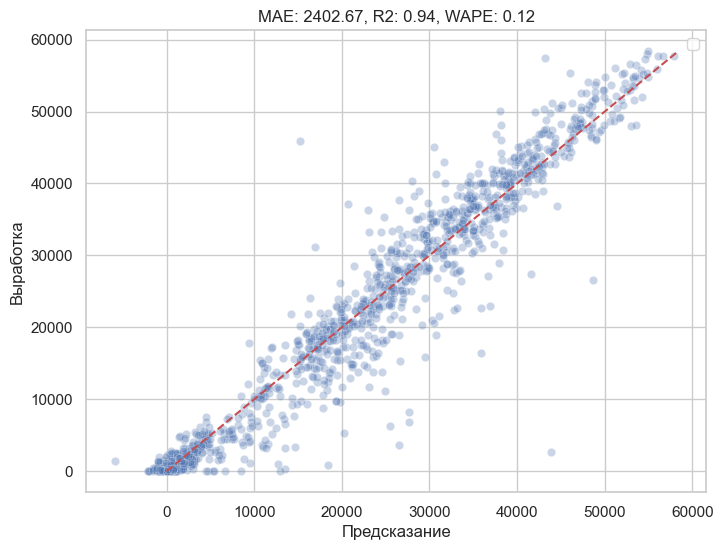

In [ ]:
histGradientBoosting_GSCV = GridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_for_GradientBoosting,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

histGradientBoosting_GSCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosting_GSCV.predict(x_test), y_test)


#### На обработанных данных

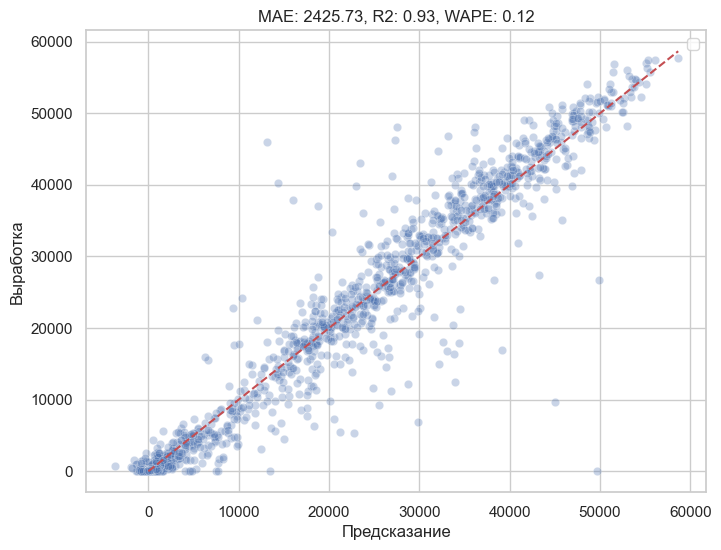

In [ ]:
histGradientBoosting_GSCV = GridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_for_GradientBoosting,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

histGradientBoosting_GSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(histGradientBoosting_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

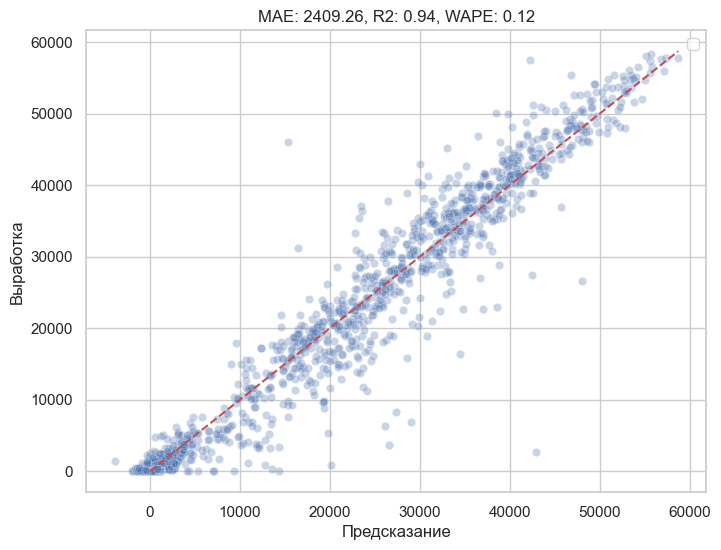

In [ ]:
histGradientBoosting_RSCV = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_GradientBoosting,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

histGradientBoosting_RSCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosting_RSCV.predict(x_test), y_test)

#### На обработанных данных

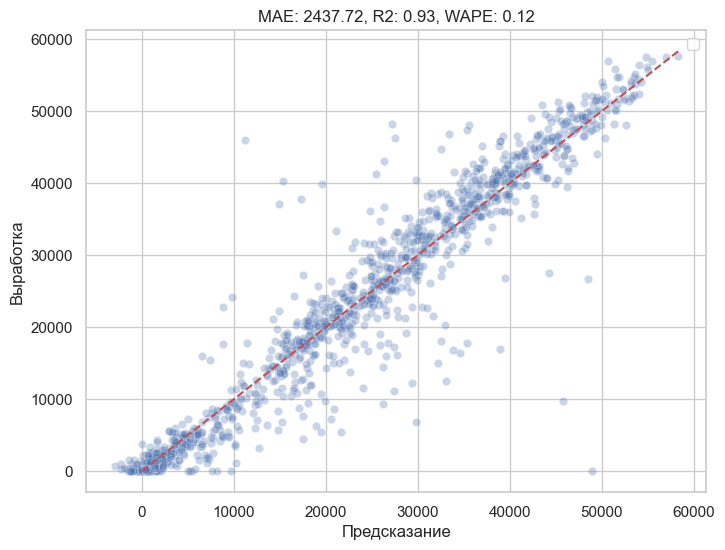

In [ ]:
histGradientBoosting_RSCV = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_GradientBoosting,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
histGradientBoosting_RSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(histGradientBoosting_RSCV.predict(x_test_p), y_test_p)

### HalvingGridSearchCV

#### На необработанных данных

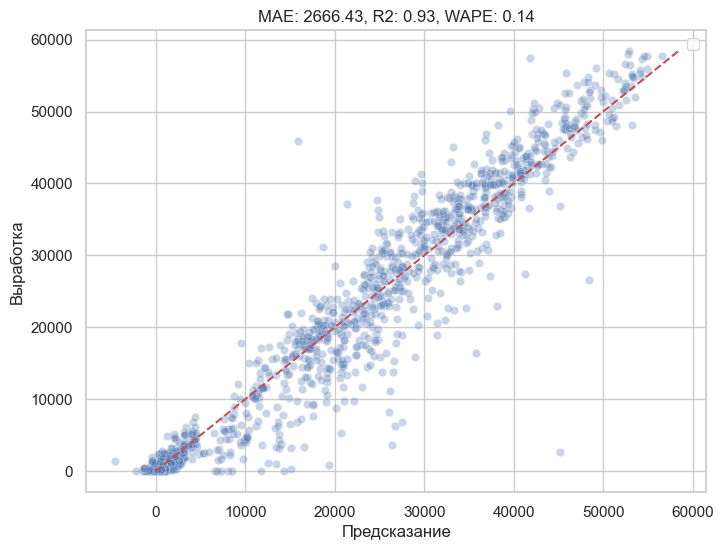

In [ ]:
histGradientBoosting_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_for_GradientBoosting,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

histGradientBoosting_HGSCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosting_HGSCV.predict(x_test), y_test)


#### На обработанных данных

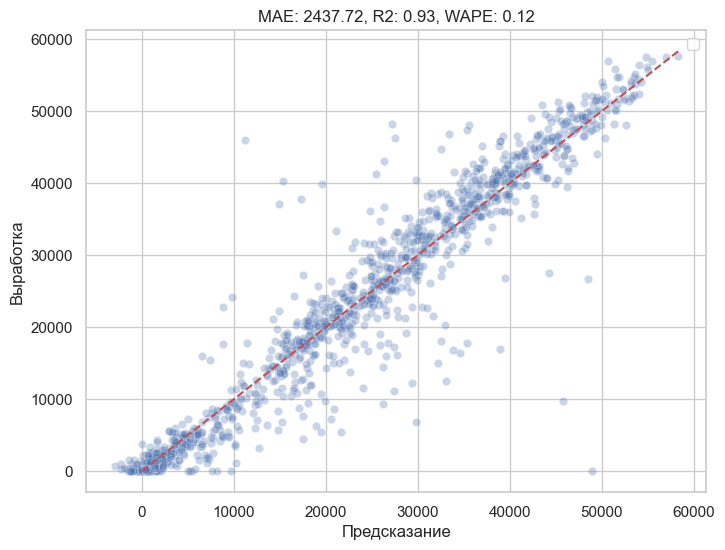

In [ ]:
histGradientBoosting_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_for_GradientBoosting,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

histGradientBoosting_HGSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(histGradientBoosting_HGSCV.predict(x_test_p), y_test_p)


### HalvingRandomSearchCV

#### На необработанных данных

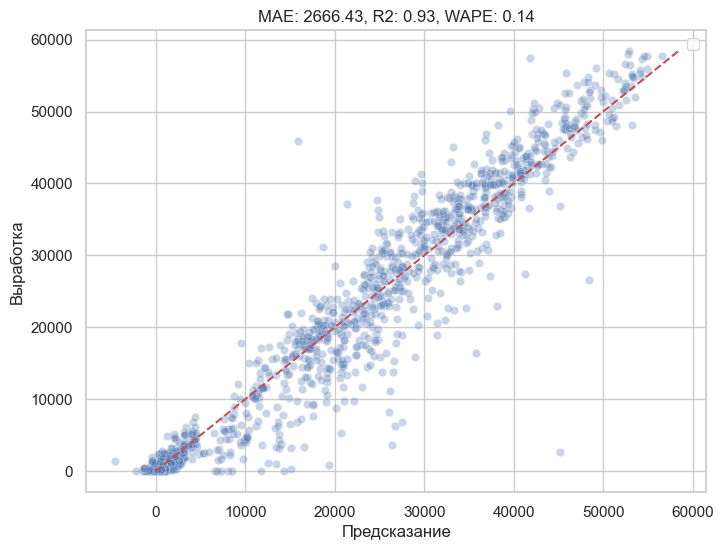

In [ ]:
histGradientBoosing_HRCV = enable_halving_search_cv.HalvingRandomSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_GradientBoosting,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

histGradientBoosing_HRCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosing_HRCV.predict(x_test), y_test)


#### На обработанных данных

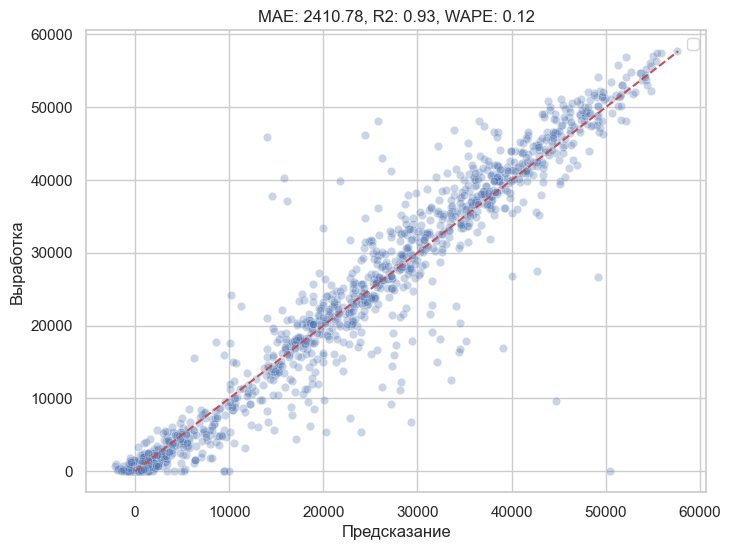

In [ ]:
histGradientBoosing_HRCV = enable_halving_search_cv.HalvingRandomSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_GradientBoosting,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

histGradientBoosing_HRCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(histGradientBoosing_HRCV.predict(x_test_p), y_test_p)


## Нейронная сеть

Инициализация сетки параметров нейронной сети 

In [30]:
param_grid_for_MLP = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

### GridSearchCV

#### На необработанных данных

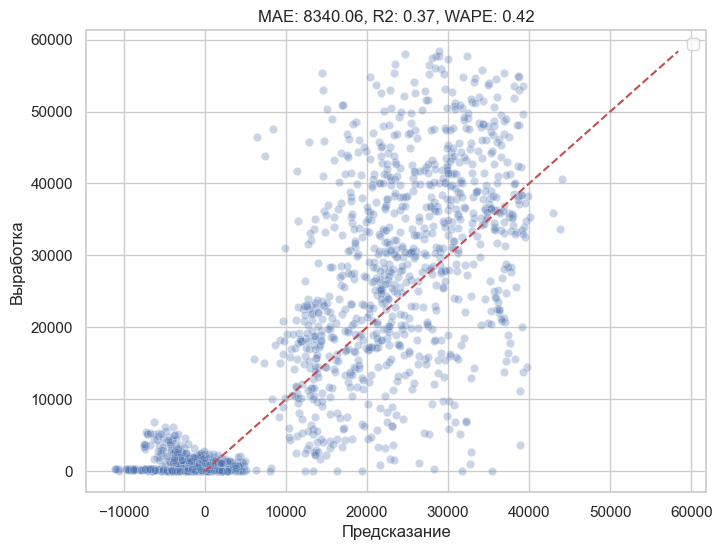

In [31]:
MLP_GSCV = GridSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_grid=param_grid_for_MLP,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

MLP_GSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_GSCV.predict(x_test), y_test)


#### На обработанных данных

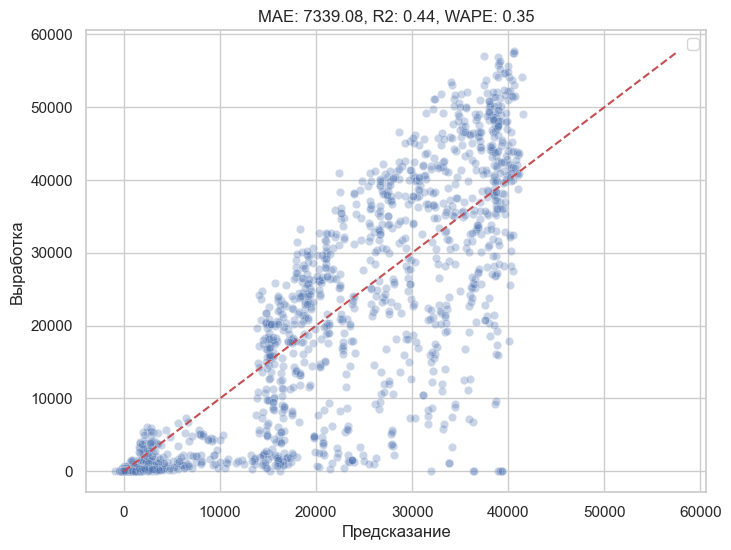

In [ ]:
MLP_GSCV = GridSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_grid=param_grid_for_MLP,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

MLP_GSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

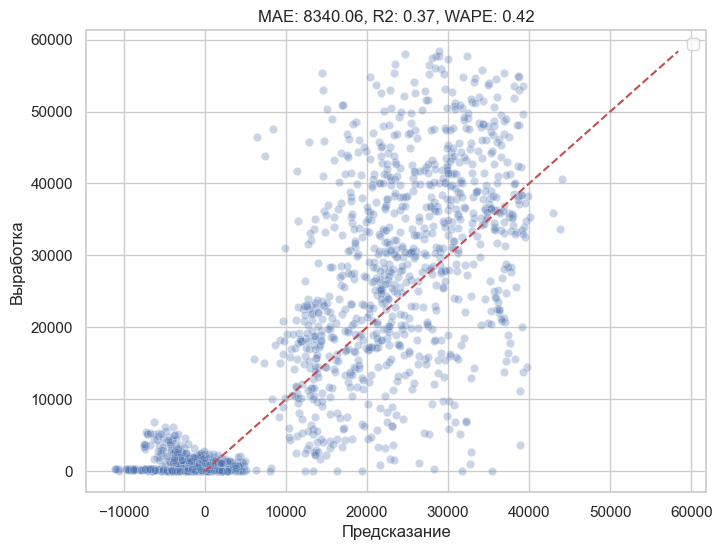

In [ ]:
MLP_RSCV = RandomizedSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_distributions=param_grid_for_MLP,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

MLP_RSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_RSCV.predict(x_test), y_test)


#### На обработанных данных

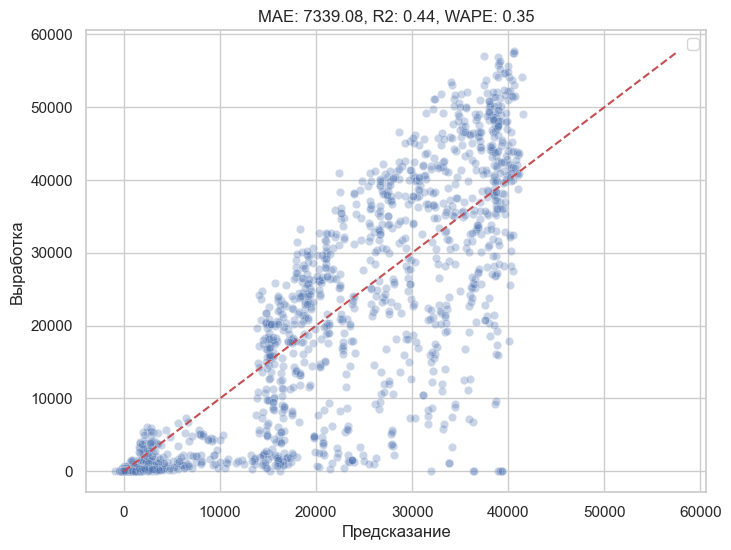

In [ ]:
MLP_RSCV = RandomizedSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_distributions=param_grid_for_MLP,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

MLP_RSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_RSCV.predict(x_test_p), y_test_p)


### HalvingGridSearchCV

#### На необработанных данных

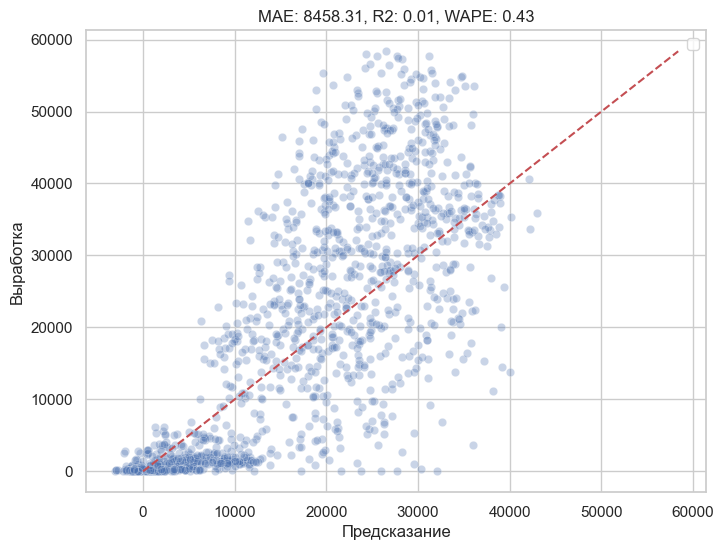

In [ ]:
MLP_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_grid_for_MLP,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

MLP_HGSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_HGSCV.predict(x_test), y_test)

#### На обработанных данных

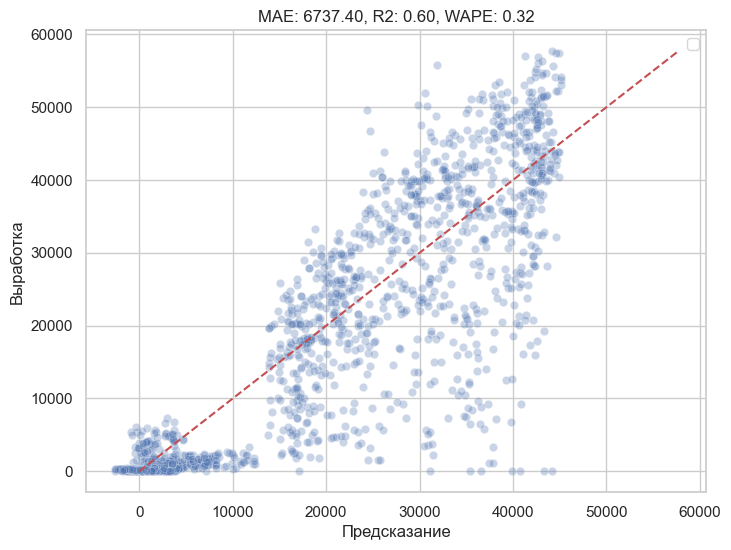

In [ ]:
MLP_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_grid_for_MLP,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

MLP_HGSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_HGSCV.predict(x_test_p), y_test_p)

### HalvingRandomSearchCV


#### На необработанных данных

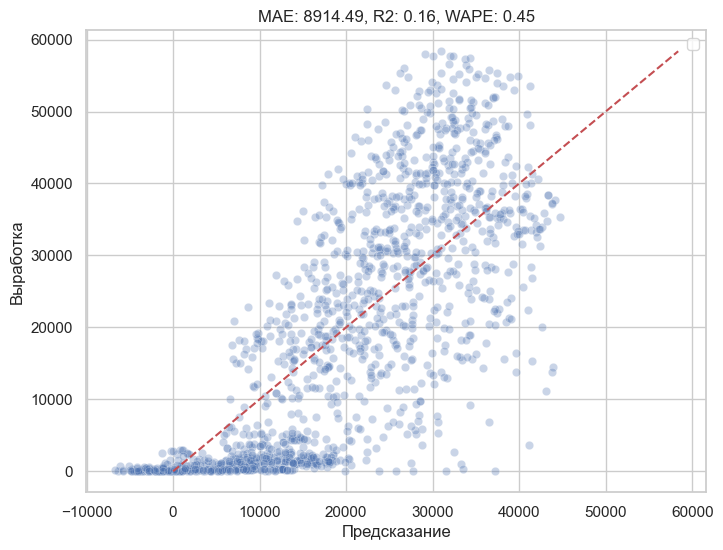

In [ ]:
MLP_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_distributions=param_grid_for_MLP,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

MLP_HRSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_HRSCV.predict(x_test), y_test)


#### На обработанных данных

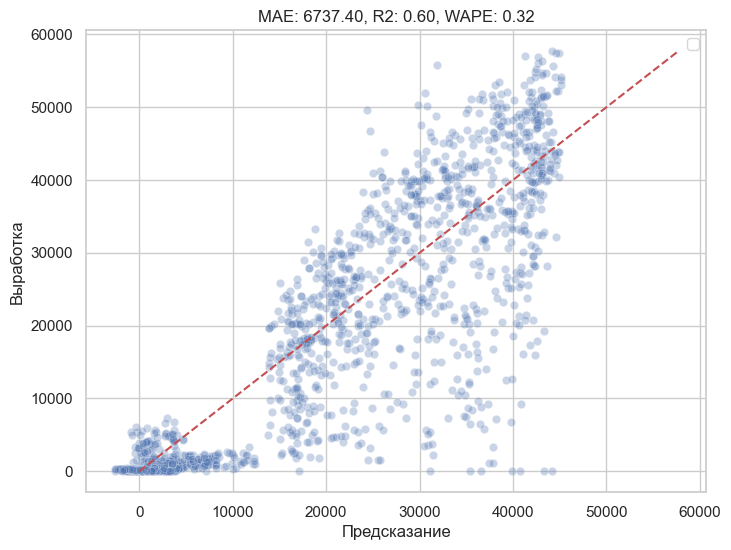

In [ ]:
MLP_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=MAX_ITERATIONS),
    param_distributions=param_grid_for_MLP,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

MLP_HRSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_HRSCV.predict(x_test_p), y_test_p)
